# EDA

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 200)

Importación datos

In [2]:
from pathlib import Path

DATA_DIR = Path("datos")

CLOSE_WIDE_PATH = DATA_DIR / "close_wide.csv"
OHLCV_WIDE_PATH = DATA_DIR / "precios_ohlcv_wide.csv"
OHLCV_LONG_PATH = DATA_DIR / "precios_ohlcv_long.csv"

print(CLOSE_WIDE_PATH)
print(OHLCV_WIDE_PATH)
print(OHLCV_LONG_PATH)

# Cargar precios de cierre en formato horizontal
close_wide = pd.read_csv(CLOSE_WIDE_PATH, parse_dates=True)
print("\nPrecios de cierre en formato horizontal:")
print(close_wide.head())

# Cargar precios OHLCV en formato horizontal
ohlcv_wide = pd.read_csv(OHLCV_WIDE_PATH, parse_dates=True)
print("\nPrecios OHLCV en formato horizontal:")
print(ohlcv_wide.head())

# Cargar precios OHLCV en formato vertical
ohlcv_long = pd.read_csv(OHLCV_LONG_PATH, parse_dates=True)
print("\nPrecios OHLCV en formato vertical:")
print(ohlcv_long.head())

datos\close_wide.csv
datos\precios_ohlcv_wide.csv
datos\precios_ohlcv_long.csv

Precios de cierre en formato horizontal:
         Date       AMZN      GOOGL       META       MSFT      NVDA         SPY       TSLA
0  2014-01-02  19.898500  27.627516  54.284016  30.694443  0.373844  148.580261  10.006667
1  2014-01-03  19.822001  27.425976  54.135174  30.487936  0.369365  148.555923   9.970667
2  2014-01-06  19.681499  27.731758  56.754623  29.843655  0.374315  148.125412   9.800000
3  2014-01-07  19.901501  28.266378  57.469009  30.074930  0.380444  149.035156   9.957333
4  2014-01-08  20.096001  28.325201  57.776592  29.538017  0.385630  149.067627  10.085333

Precios OHLCV en formato horizontal:
         Date  Close_AMZN  Close_GOOGL  Close_META  Close_MSFT  Close_NVDA   Close_SPY  Close_TSLA  High_AMZN  High_GOOGL  High_META  High_MSFT  High_NVDA    High_SPY  High_TSLA   Low_AMZN  \
0  2014-01-02   19.898500    27.627516   54.284016   30.694443    0.373844  148.580261   10.006667    1

Establecemos que ticker vamos a usar

In [3]:
ohlcv_long.columns = [str(col).strip() for col in ohlcv_long.columns]

print(ohlcv_long.columns.tolist())
ohlcv_long.head()
tickers = sorted(ohlcv_long["Ticker"].unique().tolist())
print("Tickers detectados:")
print(tickers)


['Date', 'Ticker', 'Close', 'High', 'Low', 'Open', 'Volume']
Tickers detectados:
['AMZN', 'GOOGL', 'META', 'MSFT', 'NVDA', 'SPY', 'TSLA']


Comprobamos máximos y mínimos viendo que todo está correcto 

In [4]:
ohlcv_long.info()
summary_dates = (
    ohlcv_long
    .groupby("Ticker")["Date"]
    .agg(["min", "max", "count"])
    .reset_index()
)

summary_dates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18480 entries, 0 to 18479
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    18480 non-null  object 
 1   Ticker  18480 non-null  object 
 2   Close   18480 non-null  float64
 3   High    18480 non-null  float64
 4   Low     18480 non-null  float64
 5   Open    18480 non-null  float64
 6   Volume  18480 non-null  int64  
dtypes: float64(4), int64(1), object(2)
memory usage: 1010.8+ KB


,Ticker,min,max,count
0,AMZN,2014-01-02,2024-06-28,2640
1,GOOGL,2014-01-02,2024-06-28,2640
2,META,2014-01-02,2024-06-28,2640
3,MSFT,2014-01-02,2024-06-28,2640
4,NVDA,2014-01-02,2024-06-28,2640
5,SPY,2014-01-02,2024-06-28,2640
6,TSLA,2014-01-02,2024-06-28,2640


In [5]:
data_long = ohlcv_long.sort_values(["Ticker", "Date"]).reset_index(drop=True)

data_long.head()

,Date,Ticker,Close,High,Low,Open,Volume
0,2014-01-02,AMZN,19.898500,19.9680,19.701000,19.940001,42756000
1,2014-01-03,AMZN,19.822001,20.1355,19.811001,19.914499,44204000
2,2014-01-06,AMZN,19.681499,19.8500,19.421000,19.792500,63412000
3,2014-01-07,AMZN,19.901501,19.9235,19.714500,19.752001,38320000
4,2014-01-08,AMZN,20.096001,20.1500,19.802000,19.923500,46330000


In [6]:
volume_wide = (
    ohlcv_long
    .pivot(index="Date", columns="Ticker", values="Volume")
    .sort_index()
)

display(volume_wide.head())

Ticker,AMZN,GOOGL,META,MSFT,NVDA,SPY,TSLA
Date,,,,,,,
2014-01-02,42756000,72783144,43195500,30632200,260092000,119636900,92826000
2014-01-03,44204000,66601332,38246200,31134800,259332000,81390600,70425000
2014-01-06,63412000,70701228,68852600,43603700,409492000,108028200,80416500
2014-01-07,38320000,102001896,77207400,35802800,333288000,86144200,75511500
2014-01-08,46330000,89610300,56682400,59971700,308192000,96582300,92448000


## Análisis de precios

Aunque el gráfico de precios absolutos permite visualizar la evolución histórica de cada activo, no es adecuado para comparar directamente cuál ha sido mejor inversión. Cada acción parte de un nivel de precio distinto y puede haber sufrido splits, cambios corporativos o diferencias estructurales en su cotización. Por ello, un precio más alto no implica necesariamente mayor rentabilidad. Para comparar correctamente los activos es necesario transformar los precios en retornos porcentuales, precios normalizados con base 100 o rentabilidades acumuladas, ya que estas medidas muestran el crecimiento relativo de una inversión inicial equivalente en cada activo.

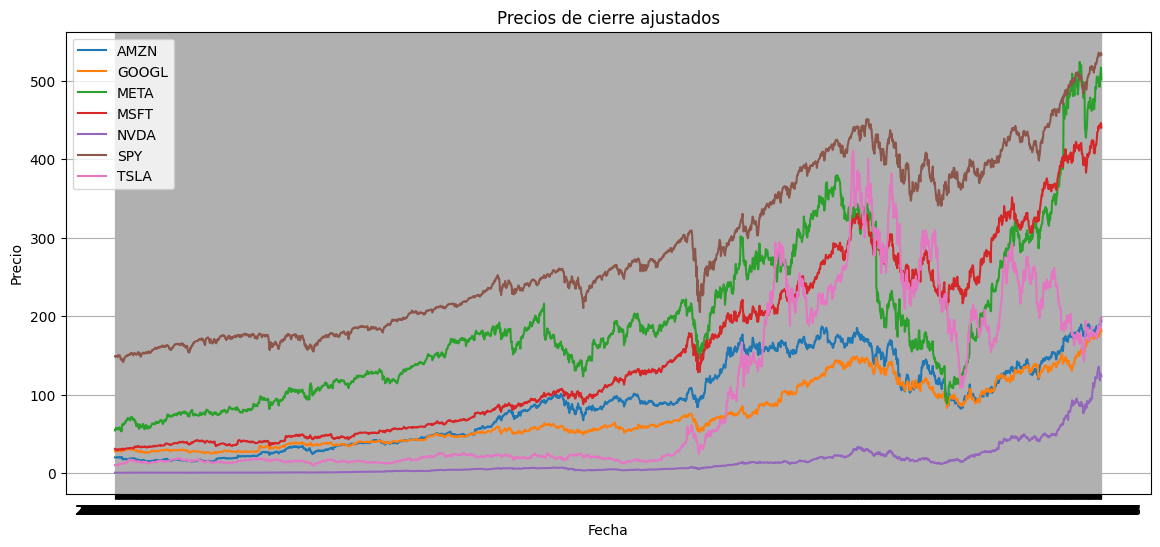

In [7]:
# Precios absolutos de cierre ajustados
plt.figure(figsize=(14, 6))

for ticker in tickers:
    columna = f"Close_{ticker}"
    plt.plot(ohlcv_wide["Date"], ohlcv_wide[columna], label=ticker)

plt.title("Precios de cierre ajustados")
plt.xlabel("Fecha")
plt.ylabel("Precio")
plt.legend()
plt.grid(True)
plt.show()

Normalizar precios base 100. Esto permite comparar cuánto ha crecido cada activo desde su primera fecha disponible.

In [ ]:
normalized_prices = close_wide / close_wide.iloc[0] * 100

display(normalized_prices.head())

plt.figure(figsize=(14, 6))

for ticker in tickers:
    columna = f"Close_{ticker}"
    plt.plot(normalized_prices["Date"], normalized_prices[columna], label=ticker)

plt.title("Precios normalizados: base 100")
plt.xlabel("Fecha")
plt.ylabel("Índice base 100")
plt.legend()
plt.show()

NameError: name 'df' is not defined